# Hemoflow Verification Document

This document outlines the process for verifying the HemoFlow C++ software package, which is based on the Palabos lattice–Boltzmann CFD solver framework. As the Palabos package is already well verified, our test cases focus only on the domain-specific features, such as the arbitrary parabolic inlet profile, Murray’s law-based outlet flow rates, and porous-layer stent modelling.

Three test cases were prepared:

- Straight pipe flow (Poiseuille flow) using our custom voxelisation process
- Realistic sidewall aneurysm from the Aneurisk database (https://ecm2.mathcs.emory.edu/aneuriskweb/about)
- Realistic sidewall aneurysm from the AneuX morphology database (https://github.com/hirsch-lab/aneuxdb)

Importing python packages for evaluation

In [23]:
import pandas as pd
import seaborn as sns

## Straight pipe flow (Poiseuille flow) 

As cerebral vessel sections can be represented as a branched system of curved pipes, our initial verification was performed on a straight pipe flow, commonly referred to as Poiseuille flow ([https://en.wikipedia.org/wiki/Hagen–Poiseuille_equation](https://en.wikipedia.org/wiki/Hagen%E2%80%93Poiseuille_equation)). This case provides an analytical solution for both the fully developed velocity profile and the pressure drop across a given section.

The following features were examined, and their outcomes are summarised below:

- Startup ramping process to eliminate transient effects from the initial condition
    - For a straight geometry, a pressure wave was observed, which required a long time to decay. When tested on a patient-specific case, these waves dissipated almost immediately due to the pronounced curvature of the vessel section.
- Time-dependent volume flow rate (VFR) condition read from a text file
    - The normalised VFR curve values are read from text files, and the parabolic velocity profile is scaled according to the prescribed boundary condition velocity magnitude and the normalised curve.
- Parabolic velocity boundary condition setup
    - The algorithm can impose velocity profiles in arbitrary directions and positions, which is crucial since outlets may lie near the corners of the computational domain. The boundary condition can also prescribe both inlet and outlet VFR values.
- Zero-pressure boundary condition
    - As noted previously, this condition does not dampen pressure waves.
- Porous layer resistance applied to stent voxels
    - Since this feature is central to our current application, we examined its dependency on voxel size as well as the influence of stent surface curvature.

### Voxel size dependence

#### Pressure drop

In the straight pipe scenario, we observed that the pressure wave oscillated between the inlet and the outlet while using a constant pipe flow profile at the inlet. To address this oscillation, a ramping inlet condition was applied, increasing the flow rate from zero to the desired volume flow rate at $t=0$ over the first half of the warm-up phase duration. The duration of the warm-up phase iterations was based on the maximum number of voxels in the x, y, or z direction.

The sensitivity analysis of the pressure drop indicates a notable difference between the 0.3 mm and 0.2 mm cases, while the convergence for smaller dx values remains less consistent. This behaviour may be attributed to the presence of residual pressure waves during the warm-up phase. However, due to computational limitations, the warm-up phase was not extended. We expect that in highly curved blood vessel geometries, these artificial pressure waves will dissipate quickly.

In [24]:
pipe_dx=pd.read_csv('./input/pipe_dx_dp_sensitivity.csv')
pipe_dx.drop(index=pipe_dx.index[0], inplace=True)
pipe_dx.drop(columns=["Unnamed: 0", 'iteration'], inplace=True)
pipe_dx

,run_id,dx,u,l,q,dt,elem,save_dt,t_end,pressure_drop
1,1,0.30,0.5,0,0,0.00001,50000,1.0,2.5,90.671189
2,2,0.20,0.5,0,0,0.00001,50000,1.0,2.5,89.130026
3,3,0.15,0.5,0,0,0.00001,50000,1.0,2.5,86.024537
4,4,0.10,0.5,0,0,0.00001,50000,1.0,2.5,85.855040
5,5,0.08,0.5,0,0,0.00001,50000,1.0,2.5,86.737874


[Text(0.5, 1.0, 'Poiseuille flow: Pressure drop in function of voxel size')]

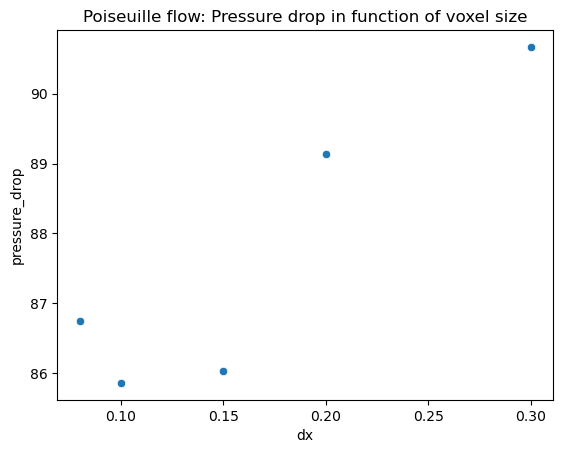

In [25]:
ax= sns.scatterplot(pipe_dx, x='dx', y='pressure_drop')
ax.set(title='Poiseuille flow: Pressure drop in function of voxel size')

#### Pressure drop with a straight flow diverter

TODO

#### Pressure drop with a curved flow diverter

TODO

#### Velocity profiles

Velocity profiles were extracted just before the outlet boundary condition along the x-axis. The voxel resolution used was 0.3 mm for the coarse grid and 0.08 mm for the fine grid. The coarse profile demonstrates good agreement with the analytical profile, with only the interpolation error from the post-processing algorithm being noticeable. In the fine grid, a minor asymmetry is visible, which remains under investigation.

##### Coarse

![](input/profile_comp_coarse.png "coarse profile")

##### Fine

![](input/profile_comp_fine.png "fine profile")

TODO: asymmetry!

### Womersley profile
TODO

## Aneurisk testcase

General description eqs etc

### Voxel size dependence

In [26]:
aneurisk_dx=pd.read_csv('./input/aneurisk_dx_STAV_sensitivity.csv')
aneurisk_dx.drop(index=aneurisk_dx.index[0], inplace=True)
aneurisk_dx.drop(columns=["Unnamed: 0", 'iteration'], inplace=True)
aneurisk_dx

,run_id,dx,u,l,q,dt,elem,save_dt,t_end,ane_0_velocity_vol_avg
1,1,0.20,0.5,0,0,0.00001,50000,0.016,0.8,0.068581
2,2,0.15,0.5,0,0,0.00001,50000,0.016,0.8,0.075535
3,3,0.10,0.5,0,0,0.00001,50000,0.016,0.8,0.079838
4,4,0.08,0.5,0,0,0.00001,50000,0.016,0.8,0.081336
5,5,0.06,0.5,0,0,0.00001,50000,0.016,0.8,0.081932
6,6,0.05,0.5,0,0,0.00001,50000,0.016,0.8,0.081930


[Text(0.5, 1.0, 'Aneurysm flow: Space and time averaged velocity in function of voxel size')]

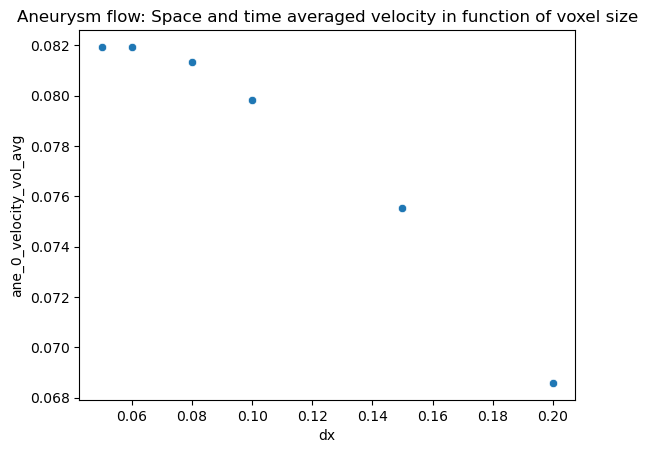

In [27]:
ax=sns.scatterplot(aneurisk_dx, x='dx', y='ane_0_velocity_vol_avg')
ax.set(title='Aneurysm flow: Space and time averaged velocity in function of voxel size')

### Timestep length dependency

In [28]:
aneurisk_dt=pd.read_csv('./input/aneurisk_dt_STAV_sensitivity.csv')
aneurisk_dt.drop(index=aneurisk_dt.index[0], inplace=True)
aneurisk_dt.drop(columns=["Unnamed: 0", 'iteration'], inplace=True)
aneurisk_dt

,run_id,dt,u,l,q,dx,elem,save_dt,t_end,ane_0_velocity_vol_avg
1,1,0.000030,0.5,0,0,0.08,50000,0.016,0.8,0.080689
2,2,0.000020,0.5,0,0,0.08,50000,0.016,0.8,0.081357
3,3,0.000010,0.5,0,0,0.08,50000,0.016,0.8,0.081336
4,4,0.000009,0.5,0,0,0.08,50000,0.016,0.8,0.081889
5,5,0.000008,0.5,0,0,0.08,50000,0.016,0.8,0.081092


[Text(0.5, 1.0, 'Aneurysm flow: Space and time averaged velocity in function of timestep size')]

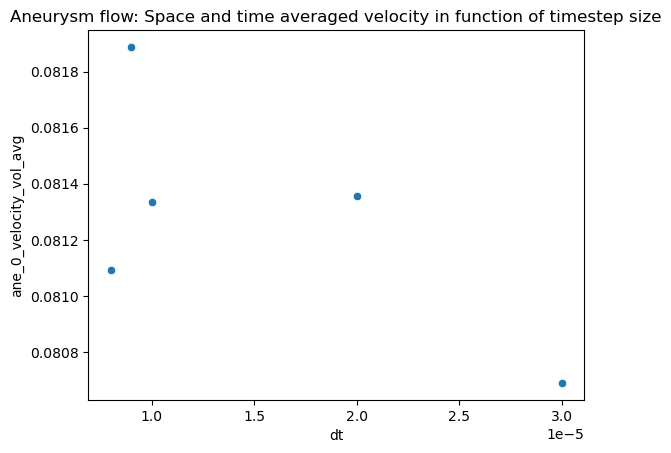

In [29]:
ax=sns.scatterplot(aneurisk_dt, x='dt', y='ane_0_velocity_vol_avg')
ax.set(title='Aneurysm flow: Space and time averaged velocity in function of timestep size')

### Save time dependency

In [30]:
aneurisk_save_dt=pd.read_csv('./input/aneurisk_savedt_STAV_sensitivity.csv')
aneurisk_save_dt.drop(index=aneurisk_save_dt.index[0], inplace=True)
aneurisk_save_dt.drop(columns=["Unnamed: 0", 'iteration'], inplace=True)
aneurisk_save_dt

,run_id,save_dt,u,l,q,dt,dx,elem,t_end,ane_0_velocity_vol_avg
1,1,0.080000,0.5,0,0,0.00002,0.1,50000,0.8,0.078794
2,2,0.040000,0.5,0,0,0.00002,0.1,50000,0.8,0.078346
3,3,0.020000,0.5,0,0,0.00002,0.1,50000,0.8,0.080235
4,4,0.016000,0.5,0,0,0.00002,0.1,50000,0.8,0.080456
5,5,0.013333,0.5,0,0,0.00002,0.1,50000,0.8,0.081259
6,6,0.008000,0.5,0,0,0.00002,0.1,50000,0.8,0.080998
7,7,0.004000,0.5,0,0,0.00002,0.1,50000,0.8,0.081253
8,8,0.001600,0.5,0,0,0.00002,0.1,50000,0.8,0.081409


[Text(0.5, 1.0, 'Aneurysm flow: Space and time averaged velocity in function of save frequency')]

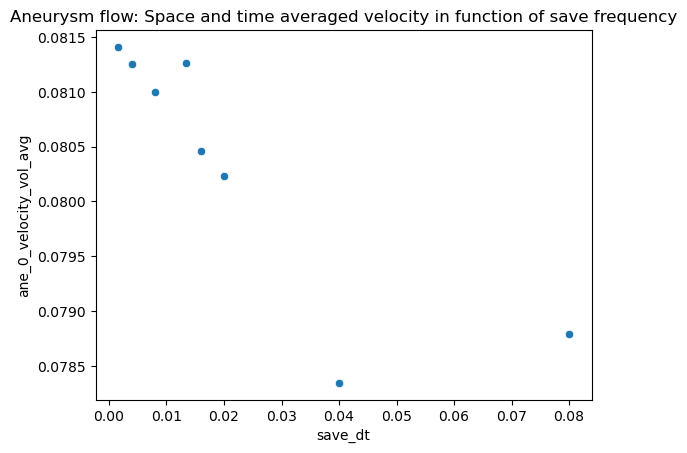

In [31]:
ax=sns.scatterplot(aneurisk_save_dt, x='save_dt', y='ane_0_velocity_vol_avg')
ax.set(title='Aneurysm flow: Space and time averaged velocity in function of save frequency')